In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('airline_passenger_satisfaction.csv')
df.shape

(129880, 24)

In [ ]:
# quick look before diving in
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## Bivariate Analysis

In [ ]:
# encode target so i can use it in calculations easily
df['satisfied'] = (df['Satisfaction'] == 'Satisfied').astype(int)
df['satisfied'].value_counts()

,count
satisfied,
0,73452
1,56428


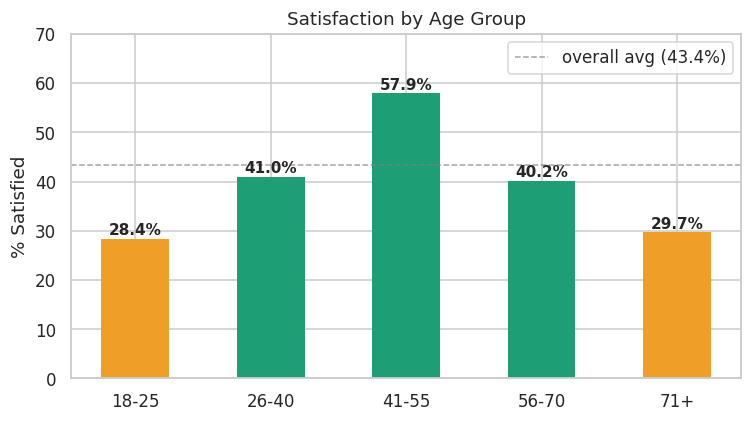

In [ ]:
# how does satisfaction change across age groups
df['age_group'] = pd.cut(df['Age'], bins=[0,25,40,55,70,100],
                         labels=['18-25','26-40','41-55','56-70','71+'])

age_sat = df.groupby('age_group', observed=True)['satisfied'].mean().mul(100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#ef9f27' if v < 40 else '#1d9e75' for v in age_sat]
bars = ax.bar(age_sat.index, age_sat.values, color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, age_sat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(df['satisfied'].mean()*100, color='gray', linestyle='--',
           linewidth=1, alpha=0.7, label=f'overall avg ({df["satisfied"].mean()*100:.1f}%)')
ax.set_ylabel('% Satisfied')
ax.set_title('Satisfaction by Age Group')
ax.set_ylim(0, 70)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# class x travel type — this combo should be interesting
ct = df.groupby(['Class','Type of Travel'], observed=True)['satisfied'].mean().mul(100).round(1).unstack()
ct

Type of Travel,Business,Personal
Class,,
Business,72.0,11.7
Economy,29.9,10.2
Economy Plus,39.3,8.7


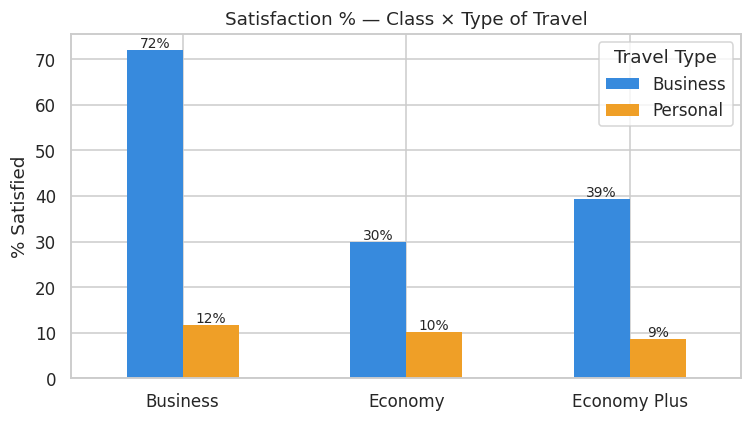

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ct.plot(kind='bar', ax=ax, color=['#378add','#ef9f27'], edgecolor='none', width=0.5)
ax.set_title('Satisfaction % — Class × Type of Travel')
ax.set_ylabel('% Satisfied')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Travel Type')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.0f}%',
                    (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                    ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# business class + business travel = 72% satisfied
# personal travel doesnt matter what class you're in, still under 12%

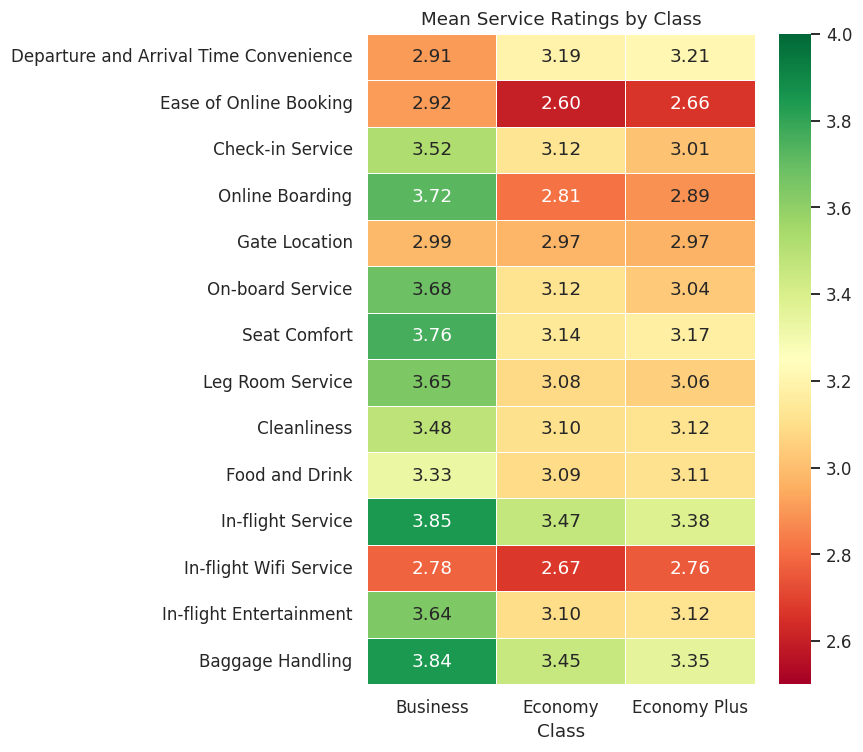

In [ ]:
# heatmap of service ratings by class
service_cols = [
    'Departure and Arrival Time Convenience', 'Ease of Online Booking',
    'Check-in Service', 'Online Boarding', 'Gate Location',
    'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service',
    'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling'
]

class_means = df.groupby('Class', observed=True)[service_cols].mean().T

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(class_means, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=2.5, vmax=4.0, linewidths=0.4, ax=ax)
ax.set_title('Mean Service Ratings by Class')
plt.tight_layout()
plt.show()